### Cell 1 — Install & Imports

In [4]:
# Cell 1: Install dependencies (run once)
!pip install numpy matplotlib seaborn scikit-learn tensorflow pillow -q

### Cell 2 — Imports

In [5]:
# Cell 2: Imports
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


### Cell 3 — Mount Drive & Config

In [6]:
# Cell 3: Mount Google Drive and set config
# from google.colab import drive
# drive.mount('/content/drive')

# DATASET_ROOT = "https://www.kaggle.com/datasets/sushantamarahatta/traffic-sign/settings"
# TRAIN_DIR    = os.path.join(DATASET_ROOT, "Train")
# TEST_DIR     = os.path.join(DATASET_ROOT, "Test")

# IMG_SIZE   = 64
# BATCH_SIZE = 32
# VAL_SPLIT  = 0.20
# SEED       = 42

# print(f"Train dir exists: {os.path.isdir(TRAIN_DIR)}")
# print(f"Test dir exists : {os.path.isdir(TEST_DIR)}")

# Cell 3: Dataset configuration for Kaggle
import os

DATASET_ROOT = "/kaggle/input/datasets/sushantamarahatta/traffic-sign/Traffic_Sign"  
TRAIN_DIR    = os.path.join(DATASET_ROOT, "Train")
TEST_DIR     = os.path.join(DATASET_ROOT, "Test")

IMG_SIZE   = 64
BATCH_SIZE = 32
VAL_SPLIT  = 0.20
SEED       = 42

print(f"Train dir exists: {os.path.isdir(TRAIN_DIR)}")
print(f"Test dir exists : {os.path.isdir(TEST_DIR)}")

Train dir exists: True
Test dir exists : True


In [7]:
import os
print(os.listdir("/kaggle/input/datasets/sushantamarahatta/traffic-sign/Traffic_Sign"))

['Dataset Description-5.txt', 'Test', 'Train']


In [8]:
# #OR: Upload from zip (alternative to Drive)
# from google.colab import files
# import zipfile

# uploaded = files.upload()
# zip_name = list(uploaded.keys())[0]
# with zipfile.ZipFile(f"/content/{zip_name}", 'r') as z:
#     z.extractall("/content/")
# print("Extracted!")

# DATASET_ROOT = "/content/Traffic_Sign"
# TRAIN_DIR    = os.path.join(DATASET_ROOT, "Train")
# TEST_DIR     = os.path.join(DATASET_ROOT, "Test")
# print(f"Train: {os.path.isdir(TRAIN_DIR)} | Test: {os.path.isdir(TEST_DIR)}")

### Cell 4: Data Analysis & Visualization

Classes     : ['Caution', 'Instructions', 'No Passing', 'OverSpeed']
Num classes : 4
Total images: 15895
  Caution               2429 images  (15.3%)
  Instructions          2848 images  (17.9%)
  No Passing            5369 images  (33.8%)
  OverSpeed             5249 images  (33.0%)


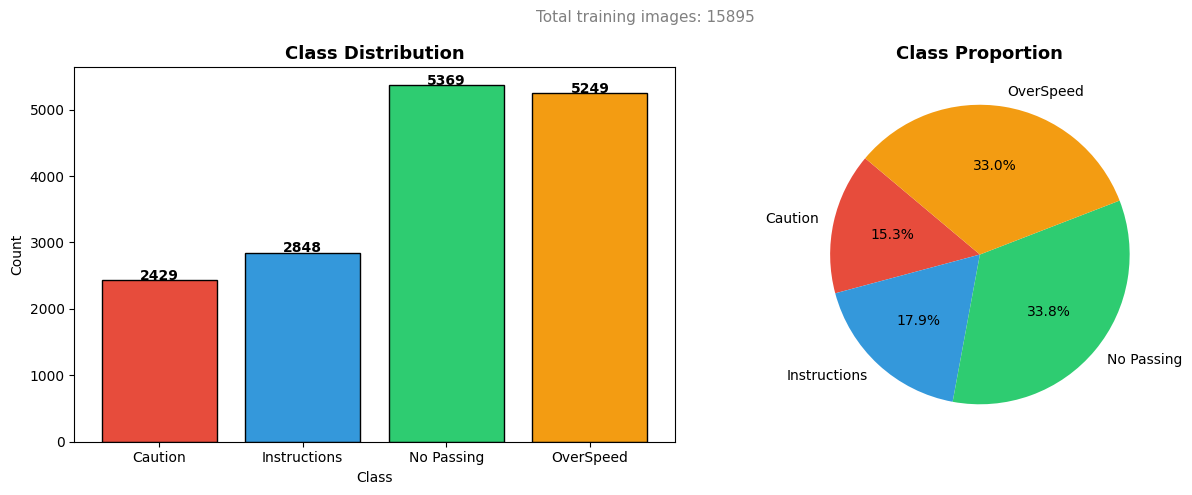

In [9]:
# Cell 4: Dataset analysis and class distribution
class_names = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])
NUM_CLASSES = len(class_names)

class_counts = {}
for cls in class_names:
    folder = os.path.join(TRAIN_DIR, cls)
    count  = len([f for f in os.listdir(folder)
                  if f.lower().endswith(('.jpg','.jpeg','.png','.ppm','.bmp'))])
    class_counts[cls] = count

total = sum(class_counts.values())
print(f"Classes     : {class_names}")
print(f"Num classes : {NUM_CLASSES}")
print(f"Total images: {total}")
for cls, cnt in class_counts.items():
    print(f"  {cls:<20} {cnt:>5} images  ({cnt/total*100:.1f}%)")

# Bar + Pie charts
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(class_names, class_counts.values(), color=colors, edgecolor='black')
axes[0].set_title("Class Distribution", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0].text(i, cnt + 5, str(cnt), ha='center', fontweight='bold')

axes[1].pie(class_counts.values(), labels=class_names,
            autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title("Class Proportion", fontsize=13, fontweight='bold')

plt.suptitle(f"Total training images: {total}", fontsize=11, color='gray')
plt.tight_layout()
plt.savefig("class_distribution_01.png", dpi=150, bbox_inches='tight')
plt.show()

### Cell 5 — Sample Images per Class

In [16]:
import os, shutil
from PIL import Image

# Copy dataset to writable location
SRC  = DATASET_ROOT
DEST = "/kaggle/working/Traffic_Sign"

if not os.path.exists(DEST):
    print("Copying dataset...")
    shutil.copytree(SRC, DEST)
    print("Done copying.")

# Clean corrupt files
removed = 0
for root, dirs, files in os.walk(DEST):
    for fname in files:
        fpath = os.path.join(root, fname)
        try:
            img = Image.open(fpath)
            img.verify()
        except Exception:
            print(f"Removing: {fpath}")
            os.remove(fpath)
            removed += 1
print(f"Removed {removed} corrupt files.")

# Update paths to use clean copy
DATASET_ROOT = DEST
TRAIN_DIR    = os.path.join(DATASET_ROOT, "Train")
TEST_DIR     = os.path.join(DATASET_ROOT, "Test")
print(f"Train exists: {os.path.isdir(TRAIN_DIR)}")
print(f"Test exists : {os.path.isdir(TEST_DIR)}")

Copying dataset...
Done copying.
Removing: /kaggle/working/Traffic_Sign/Dataset Description-5.txt
Removing: /kaggle/working/Traffic_Sign/Train/Instructions/00028_00017_00025.png
Removing: /kaggle/working/Traffic_Sign/Train/Instructions/00028_00007_00009.png
Removing: /kaggle/working/Traffic_Sign/Train/Instructions/00035_00003_00001.png
Removing: /kaggle/working/Traffic_Sign/Train/Instructions/00035_00019_00013.png
Removing: /kaggle/working/Traffic_Sign/Train/Instructions/00033_00015_00004.png
Removing: /kaggle/working/Traffic_Sign/Train/Instructions/00028_00001_00009.png
Removing: /kaggle/working/Traffic_Sign/Train/Instructions/00028_00013_00012.png
Removing: /kaggle/working/Traffic_Sign/Train/No Passing/00009_00014_00022.png
Removing: /kaggle/working/Traffic_Sign/Train/No Passing/00014_00020_00016.png
Removing: /kaggle/working/Traffic_Sign/Train/No Passing/00010_00024_00006.png
Removing: /kaggle/working/Traffic_Sign/Train/No Passing/00017_00031_00011.png
Removing: /kaggle/working/Traf

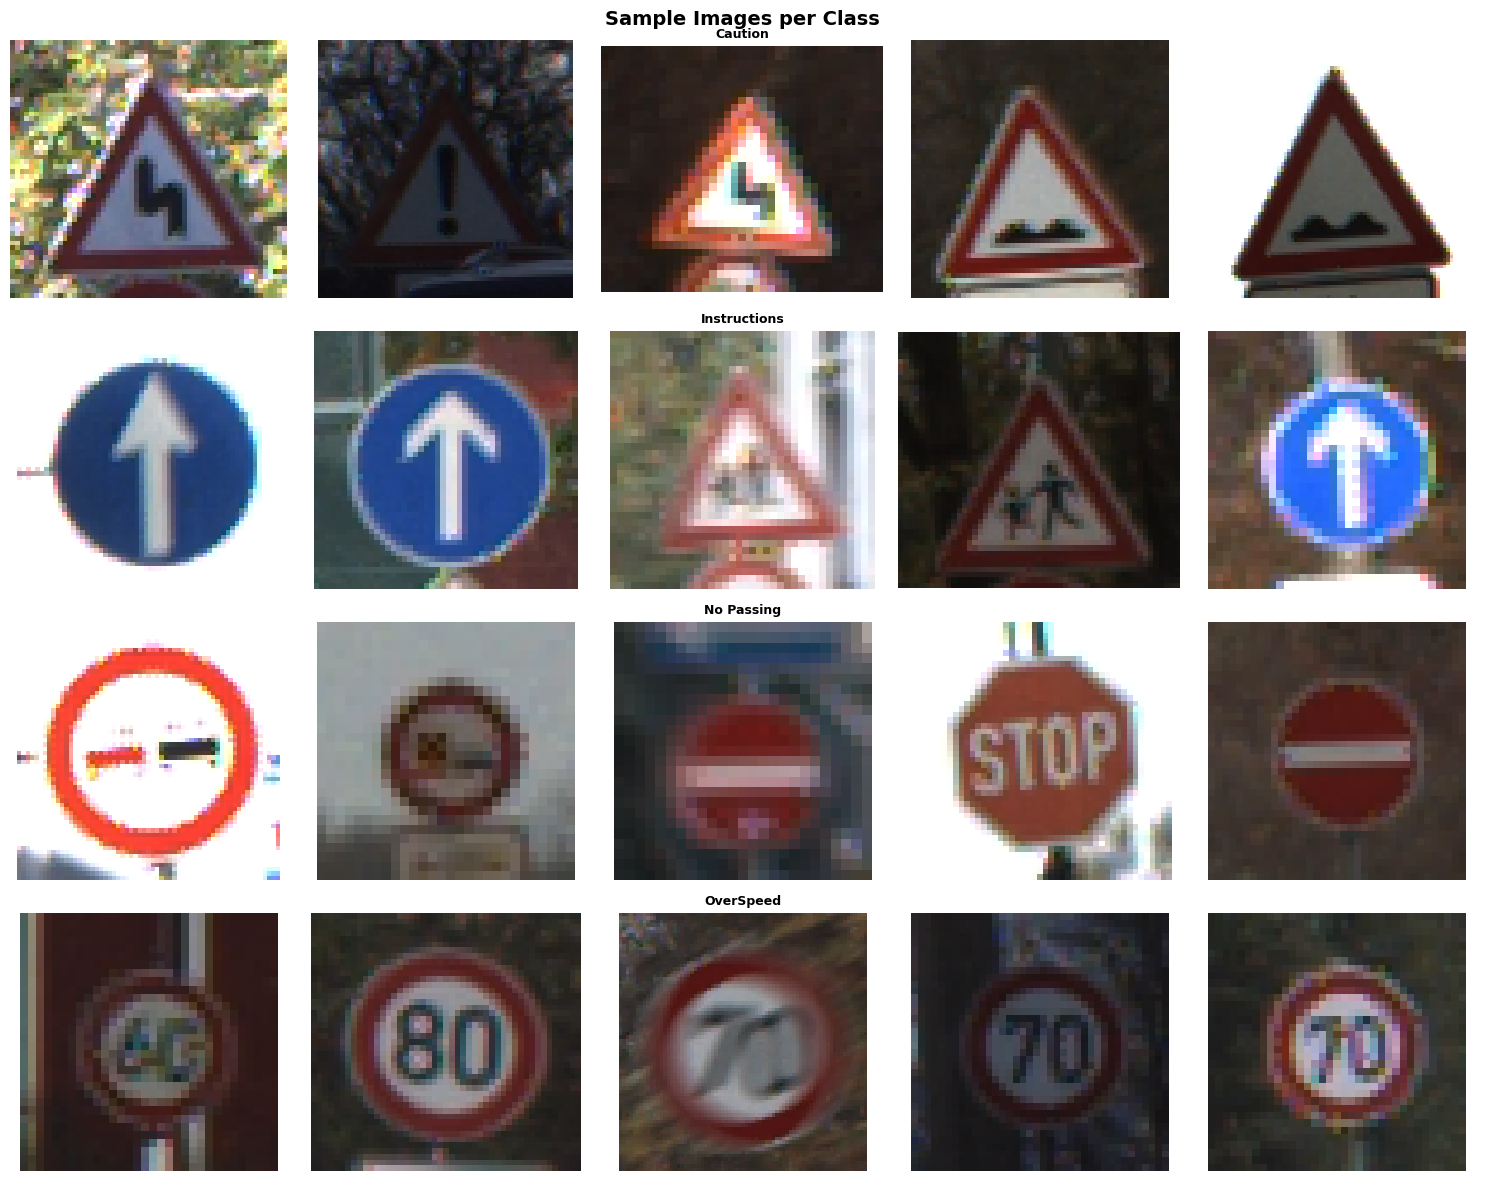

In [17]:
# Cell 5: Show sample images per class
N = 5
fig, axes = plt.subplots(NUM_CLASSES, N, figsize=(3*N, 3*NUM_CLASSES))
if NUM_CLASSES == 1: axes = [axes]

for row, cls in enumerate(class_names):
    folder = os.path.join(TRAIN_DIR, cls)
    files  = [f for f in os.listdir(folder)
              if f.lower().endswith(('.jpg','.jpeg','.png','.ppm','.bmp'))][:N]
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname)).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 2:
            axes[row][col].set_title(cls, fontsize=9, fontweight='bold')
    for col in range(len(files), N):
        axes[row][col].axis('off')

plt.suptitle("Sample Images per Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sample_images_02.png", dpi=150, bbox_inches='tight')
plt.show()

### Cell 6 — Data Generators with Augmentation

In [18]:
# Cell 6: Data generators (preprocessing + augmentation)
# Training generator — with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,   # No flip for traffic signs
    fill_mode='nearest'
)

# Validation generator — no augmentation, only rescale
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

CLASS_NAMES = list(train_generator.class_indices.keys())
print(f"Train batches : {len(train_generator)}")
print(f"Val batches   : {len(val_generator)}")
print(f"Classes       : {CLASS_NAMES}")

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.
Train batches : 397
Val batches   : 100
Classes       : ['Caution', 'Instructions', 'No Passing', 'OverSpeed']


### Cell 7 — Visualize Augmented Images

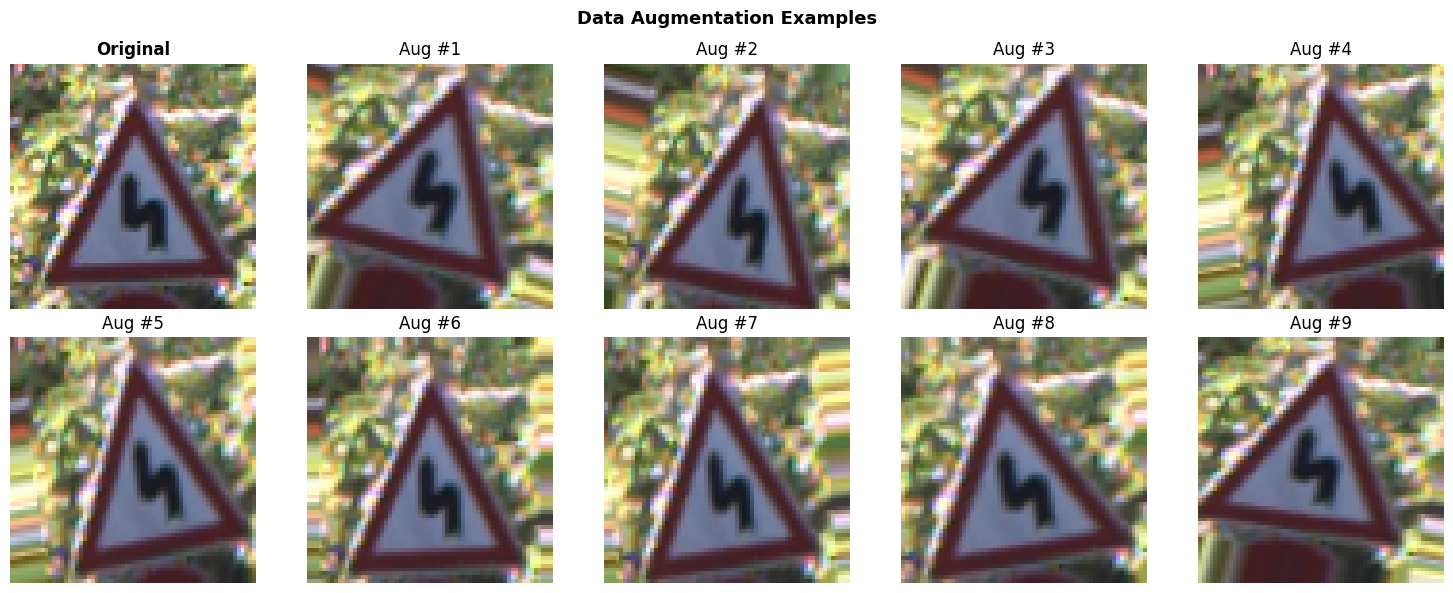

In [19]:
# Cell 7: Visualize augmentation examples
aug_only = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

# Load one sample image
sample_path = os.path.join(TRAIN_DIR, class_names[0])
sample_file = os.path.join(sample_path,
    [f for f in os.listdir(sample_path)
     if f.lower().endswith(('.jpg','.jpeg','.png'))][0])
sample_img = np.array(Image.open(sample_file).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))
sample_arr = sample_img.reshape((1,) + sample_img.shape)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0][0].imshow(sample_img)
axes[0][0].set_title("Original", fontweight='bold')
axes[0][0].axis('off')

i = 1
for batch in aug_only.flow(sample_arr, batch_size=1):
    r, c = divmod(i, 5)
    axes[r][c].imshow(batch[0].astype('uint8'))
    axes[r][c].set_title(f"Aug #{i}")
    axes[r][c].axis('off')
    i += 1
    if i >= 10: break

plt.suptitle("Data Augmentation Examples", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("augmentation_03.png", dpi=150, bbox_inches='tight')
plt.show()

### Cell 8 — Baseline CNN Architecture

In [20]:
# Cell 8: Part A-1 — Baseline CNN (3 Conv + 3 FC layers)
def build_baseline_cnn(num_classes, input_shape=(64, 64, 3)):
    model = models.Sequential([
        # Conv Block 1: 32 filters
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        # Conv Block 2: 64 filters
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Conv Block 3: 128 filters
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Flatten
        layers.Flatten(),

        # FC Layer 1
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),

        # FC Layer 2
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),

        # FC Layer 3
        layers.Dense(128, activation='relu'),

        # Output
        layers.Dense(num_classes, activation='softmax')
    ], name="Baseline_CNN")
    return model

baseline_model = build_baseline_cnn(NUM_CLASSES)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,452,804 (16.99 MB)

 Trainable params: 4,452,804 (16.99 MB)

 Non-trainable params: 0 (0.00 B)

### Cell 9 — Train Baseline CNN

In [24]:
# Cell 09: Compile and train baseline CNN
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

start = time.time()
baseline_history = baseline_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)
baseline_time = time.time() - start
print(f"\nTraining time: {baseline_time:.1f}s ({baseline_time/60:.1f} min)")

Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 63ms/step - accuracy: 0.9976 - loss: 0.0139 - val_accuracy: 0.8235 - val_loss: 21.7527 - learning_rate: 0.0010
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.9966 - loss: 0.0151 - val_accuracy: 0.8228 - val_loss: 17.3426 - learning_rate: 0.0010
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.9985 - loss: 0.0068 - val_accuracy: 0.8291 - val_loss: 25.1567 - learning_rate: 0.0010
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.9984 - loss: 0.0058 - val_accuracy: 0.8140 - val_loss: 35.1488 - learning_rate: 0.0010
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.9928 - loss: 0.0254 - val_accuracy: 0.8194 - val_loss: 14.9425 - learning_rate: 0.0010
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.9960 - loss: 0.0133 - val_accuracy: 0.8228 - val_loss: 15.2016 - learning_rate: 0.0010
Epoch 7/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.99

### Cell 10 — Plot Baseline Training Curves

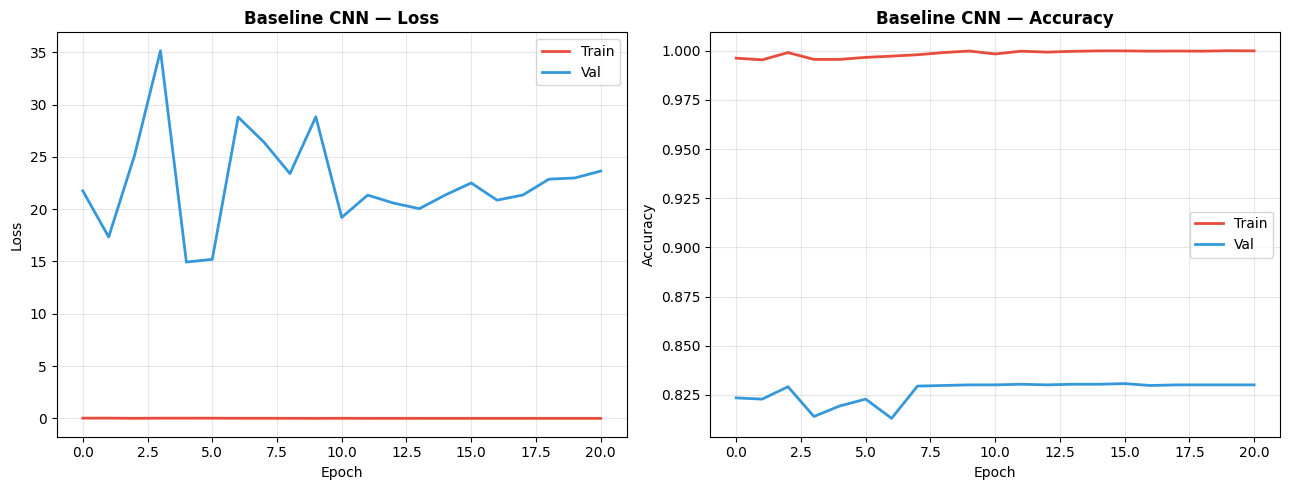

In [25]:
# Cell 10: Plot training curves
def plot_history(history, title, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(history.history['loss'],     label='Train', color='#e74c3c', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val',   color='#3498db', linewidth=2)
    axes[0].set_title(f"{title} — Loss", fontweight='bold')
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['accuracy'],     label='Train', color='#e74c3c', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val',   color='#3498db', linewidth=2)
    axes[1].set_title(f"{title} — Accuracy", fontweight='bold')
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(baseline_history, "Baseline CNN", save_path="baseline_curves_04.png")

### Cell 11 — Evaluate Baseline CNN

=== BASELINE CNN EVALUATION ===
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
  Validation Loss     : 22.5039
  Validation Accuracy : 83.07%

              precision    recall  f1-score   support

     Caution     0.4745    1.0000    0.6436       484
Instructions     1.0000    0.0581    0.1098       568
  No Passing     1.0000    0.9991    0.9995      1072
   OverSpeed     0.9990    0.9990    0.9990      1048

    accuracy                         0.8307      3172
   macro avg     0.8684    0.7641    0.6880      3172
weighted avg     0.9195    0.8307    0.7857      3172



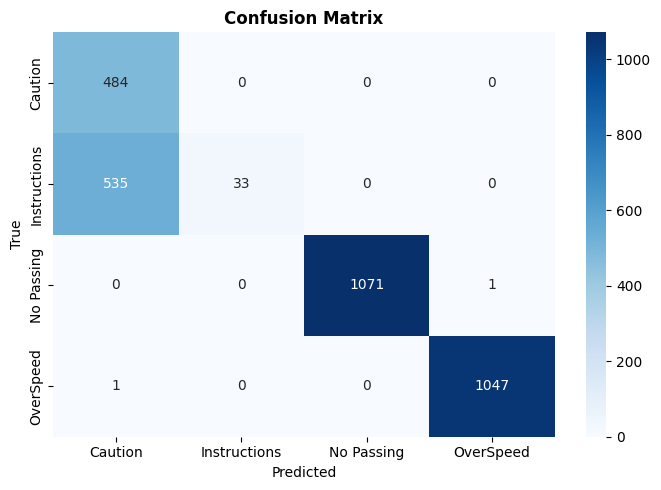

In [26]:
# Cell 11: Evaluate baseline CNN
def evaluate_model(model, generator, class_names, save_cm_path=None):
    generator.reset()
    y_pred_probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes

    loss, acc = model.evaluate(generator, verbose=0)
    print(f"  Validation Loss     : {loss:.4f}")
    print(f"  Validation Accuracy : {acc*100:.2f}%\n")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title("Confusion Matrix", fontweight='bold')
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    if save_cm_path:
        plt.savefig(save_cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    return loss, acc, y_pred, y_true

print("=== BASELINE CNN EVALUATION ===")
base_loss, base_acc, base_preds, base_labels = evaluate_model(
    baseline_model, val_generator, CLASS_NAMES, save_cm_path="baseline_cm_05.png"
)

### Cell 12 — Sample Predictions

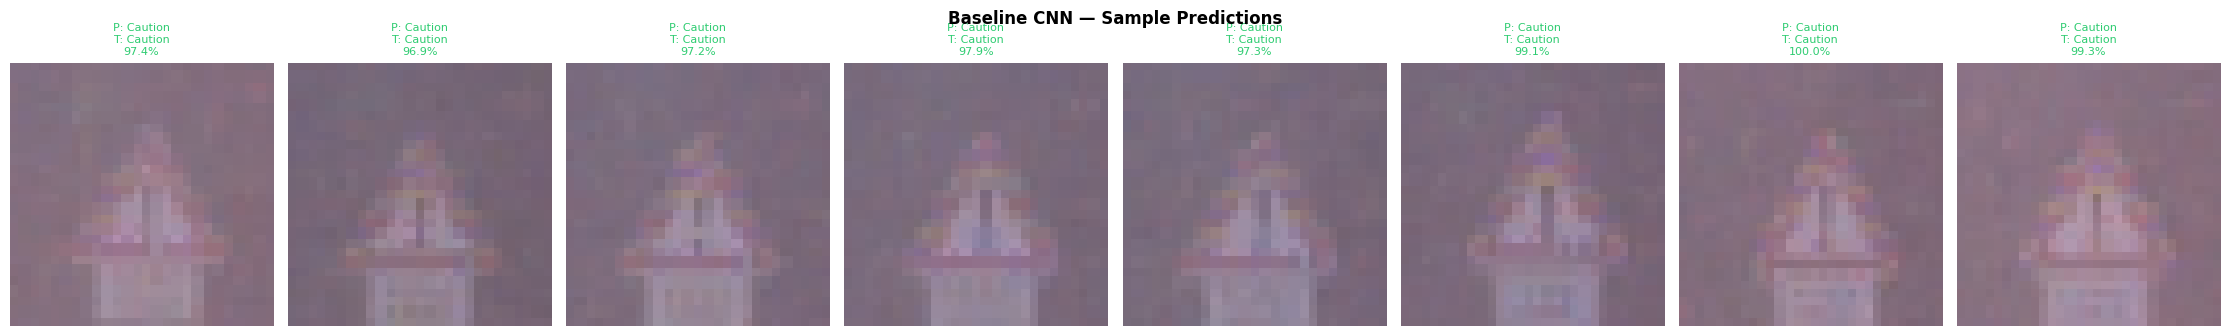

In [27]:
# Cell 12: Show sample predictions from validation set
def show_predictions(model, generator, class_names, n=8, title="Predictions", save_path=None):
    generator.reset()
    images, labels = next(generator)
    preds = model.predict(images[:n], verbose=0)

    fig, axes = plt.subplots(1, n, figsize=(n*2.8, 3.5))
    for i in range(n):
        axes[i].imshow(images[i])
        true_cls = class_names[np.argmax(labels[i])]
        pred_cls = class_names[np.argmax(preds[i])]
        conf     = np.max(preds[i]) * 100
        correct  = true_cls == pred_cls
        axes[i].set_title(
            f"P: {pred_cls}\nT: {true_cls}\n{conf:.1f}%",
            color='#2ecc71' if correct else '#e74c3c', fontsize=8)
        axes[i].axis('off')

    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(baseline_model, val_generator, CLASS_NAMES,
                 title="Baseline CNN — Sample Predictions", save_path="baseline_preds_06.png")

### Cell 13 — Deeper CNN Architecture

In [28]:
# Cell 13: Part A-2 — Deeper CNN with BatchNorm + Dropout (double the layers)
def build_deeper_cnn(num_classes, input_shape=(64, 64, 3)):
    model = models.Sequential([
        # Block 1: 32 filters × 2
        layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.1),

        # Block 2: 64 filters × 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.1),

        # Block 3: 128 filters × 2
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.2),

        # Block 4: 256 filters × 2
        layers.Conv2D(256, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.2),

        # Flatten + FC layers
        layers.GlobalAveragePooling2D(),

        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation='softmax')
    ], name="Deeper_CNN")
    return model

deeper_model = build_deeper_cnn(NUM_CLASSES)
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,472,420 (5.62 MB)

 Trainable params: 1,470,500 (5.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

### Cell 14 — Train Deeper CNN (Adam)

Epoch 1/40


2026-05-09 15:53:00.154841: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 15:53:00.296337: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


126/397 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.4669 - loss: 1.2032

2026-05-09 15:53:16.879764: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 15:53:17.020151: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


397/397 ━━━━━━━━━━━━━━━━━━━━ 50s 87ms/step - accuracy: 0.5852 - loss: 0.9376 - val_accuracy: 0.6548 - val_loss: 1.1994 - learning_rate: 5.0000e-04
Epoch 2/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.9713 - loss: 0.0941 - val_accuracy: 0.8260 - val_loss: 3.4381 - learning_rate: 5.0000e-04
Epoch 3/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.9939 - loss: 0.0220 - val_accuracy: 0.8301 - val_loss: 2.9003 - learning_rate: 5.0000e-04
Epoch 4/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9947 - loss: 0.0262
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.9947 - loss: 0.0262 - val_accuracy: 0.8285 - val_loss: 3.9146 - learning_rate: 5.0000e-04
Epoch 5/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.9981 - loss: 0.0082 - val_accuracy: 0.8294 - val_loss: 2.8937 - learning_rate: 2.5000e-04
Epoch 6/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.9

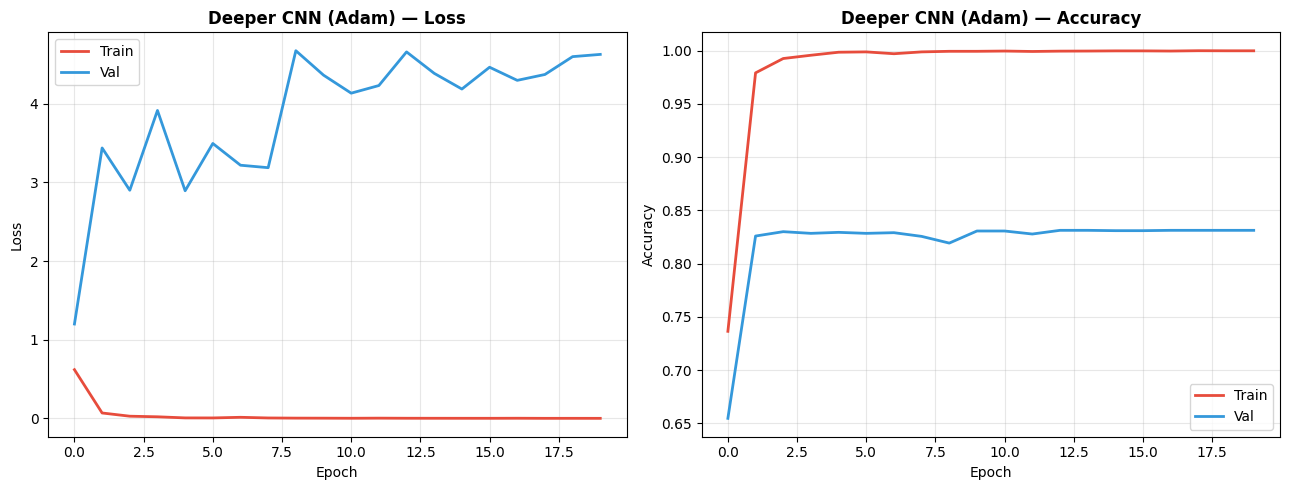

In [29]:
# Cell 14: Train deeper CNN with Adam
deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deep = [
    keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

start = time.time()
deeper_history_adam = deeper_model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=callbacks_deep,
    verbose=1
)
deeper_time_adam = time.time() - start
print(f"\nTraining time (Adam): {deeper_time_adam:.1f}s ({deeper_time_adam/60:.1f} min)")

plot_history(deeper_history_adam, "Deeper CNN (Adam)", save_path="deeper_adam_curves_07.png")

### Cell 15 — Evaluate Deeper CNN

=== DEEPER CNN (ADAM) EVALUATION ===
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
  Validation Loss     : 4.6594
  Validation Accuracy : 83.13%

              precision    recall  f1-score   support

     Caution     0.4750    1.0000    0.6440       484
Instructions     1.0000    0.0581    0.1098       568
  No Passing     1.0000    1.0000    1.0000      1072
   OverSpeed     1.0000    1.0000    1.0000      1048

    accuracy                         0.8313      3172
   macro avg     0.8687    0.7645    0.6885      3172
weighted avg     0.9199    0.8313    0.7863      3172



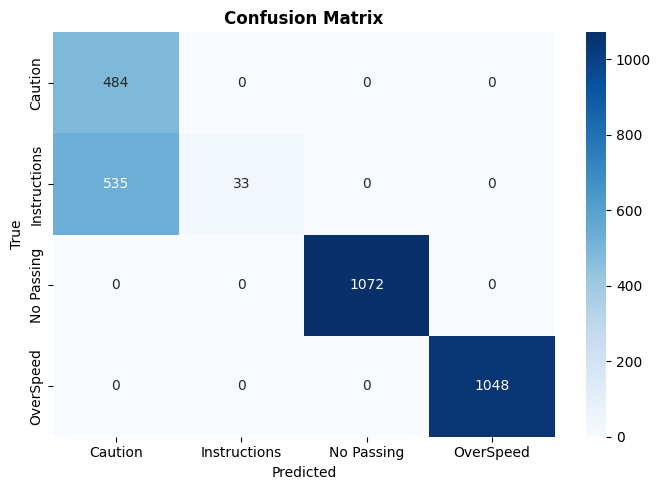

In [30]:
# Cell 15: Evaluate deeper CNN
print("=== DEEPER CNN (ADAM) EVALUATION ===")
deep_loss, deep_acc, deep_preds, deep_labels = evaluate_model(
    deeper_model, val_generator, CLASS_NAMES, save_cm_path="deeper_cm_08.png"
)

### Cell 16 — SGD Comparison

Epoch 1/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 42s 78ms/step - accuracy: 0.5530 - loss: 0.9955 - val_accuracy: 0.5003 - val_loss: 1.7826
Epoch 2/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.8725 - loss: 0.3492 - val_accuracy: 0.6844 - val_loss: 3.4929
Epoch 3/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.9790 - loss: 0.0744 - val_accuracy: 0.7588 - val_loss: 2.1838
Epoch 4/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.9881 - loss: 0.0456 - val_accuracy: 0.7856 - val_loss: 2.7266
Epoch 5/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.9929 - loss: 0.0253 - val_accuracy: 0.7815 - val_loss: 3.2916
Epoch 6/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.9945 - loss: 0.0187 - val_accuracy: 0.8042 - val_loss: 3.5780
Epoch 7/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.9950 - loss: 0.0180 - val_accuracy: 0.7973 - val_loss: 3.7426
Epoch 8/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.9952 - loss: 0.0154 - 

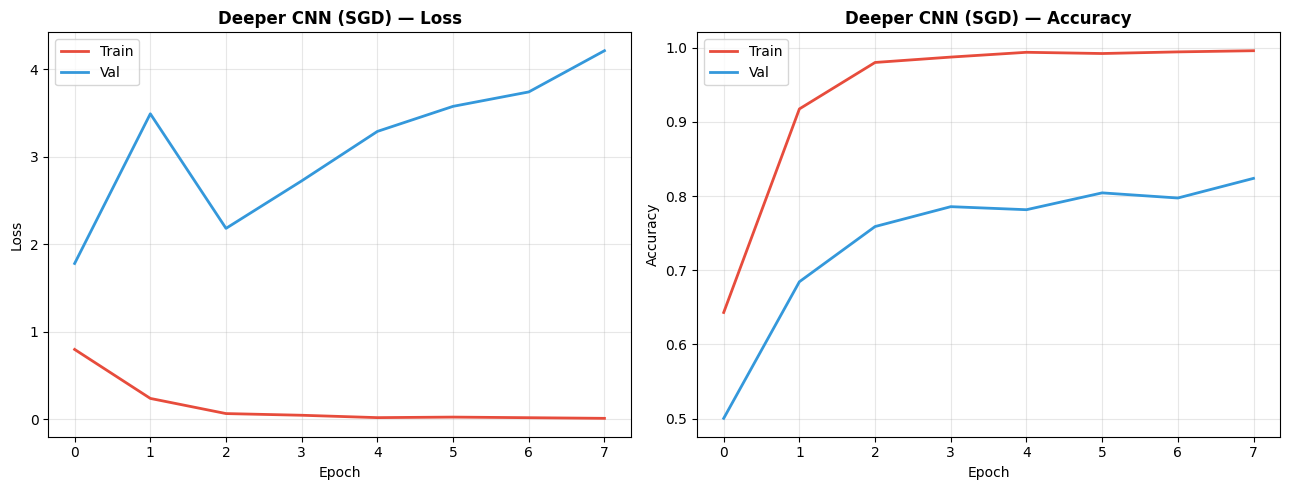

In [31]:
# Cell 16: Part A-2 Experimentation — Train deeper CNN with SGD for comparison
deeper_model_sgd = build_deeper_cnn(NUM_CLASSES)
deeper_model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
deeper_history_sgd = deeper_model_sgd.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=[keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True)],
    verbose=1
)
deeper_time_sgd = time.time() - start
print(f"\nTraining time (SGD): {deeper_time_sgd:.1f}s ({deeper_time_sgd/60:.1f} min)")

plot_history(deeper_history_sgd, "Deeper CNN (SGD)", save_path="deeper_sgd_curves_09.png")

### Cell 17 — Ablation Study (Remove BatchNorm)

Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.4294 - loss: 1.1184 - val_accuracy: 0.3509 - val_loss: 1.5272
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.7013 - loss: 0.6685 - val_accuracy: 0.4685 - val_loss: 1.9948
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.9021 - loss: 0.2615 - val_accuracy: 0.7759 - val_loss: 1.3592
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.9683 - loss: 0.1021 - val_accuracy: 0.8172 - val_loss: 1.8972
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.9907 - loss: 0.0376 - val_accuracy: 0.8131 - val_loss: 1.3839
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.9933 - loss: 0.0266 - val_accuracy: 0.8121 - val_loss: 2.3924
Epoch 7/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.9924 - loss: 0.0272 - val_accuracy: 0.8121 - val_loss: 2.7137
Epoch 8/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.9955 - loss: 0.0158 - 

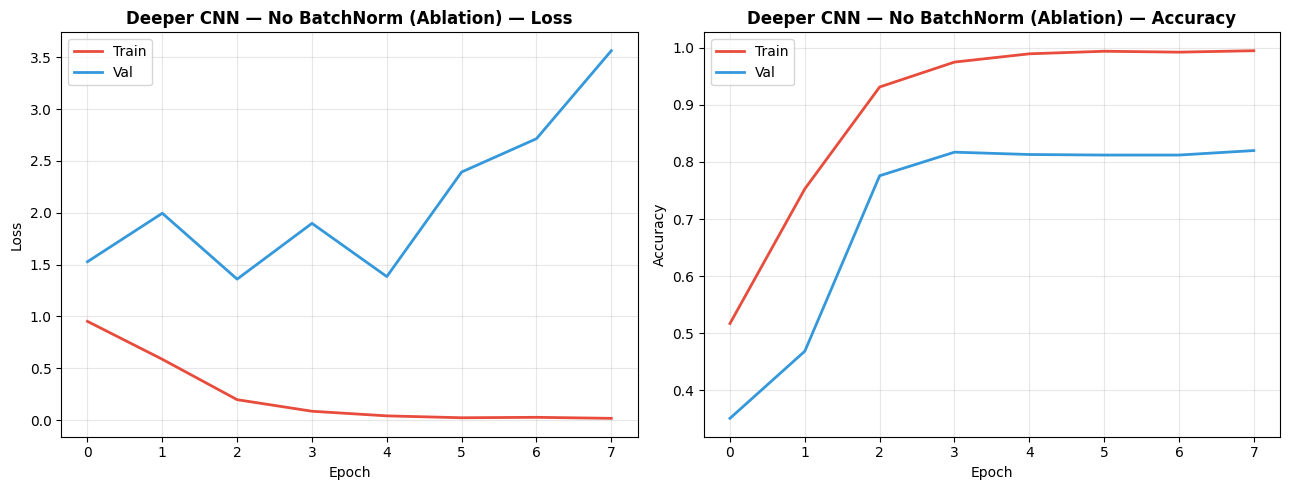


Without BatchNorm accuracy: 77.59%
With    BatchNorm accuracy: 83.13%


In [32]:
# Cell 17: Ablation study — Deeper CNN WITHOUT BatchNormalization
def build_deeper_no_bn(num_classes, input_shape=(64, 64, 3)):
    model = models.Sequential([
        layers.Conv2D(32,  (3,3), padding='same', activation='relu', input_shape=input_shape),
        layers.Conv2D(32,  (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)), layers.Dropout(0.1),

        layers.Conv2D(64,  (3,3), padding='same', activation='relu'),
        layers.Conv2D(64,  (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)), layers.Dropout(0.1),

        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)), layers.Dropout(0.2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'), layers.Dropout(0.5),
        layers.Dense(128, activation='relu'), layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ], name="Deeper_No_BN")
    return model

model_no_bn = build_deeper_no_bn(NUM_CLASSES)
model_no_bn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_no_bn = model_no_bn.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

plot_history(history_no_bn, "Deeper CNN — No BatchNorm (Ablation)", save_path="ablation_curves_10.png")
_, no_bn_acc = model_no_bn.evaluate(val_generator, verbose=0)
print(f"\nWithout BatchNorm accuracy: {no_bn_acc*100:.2f}%")
print(f"With    BatchNorm accuracy: {deep_acc*100:.2f}%")

### Cell 18 — Comparison Table

In [33]:
# Cell 18: Comparison summary — all Part A models
_, sgd_acc = deeper_model_sgd.evaluate(val_generator, verbose=0)

print("=" * 55)
print("MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Model':<30} {'Val Acc':>9} {'Time (s)':>10}")
print("-" * 55)
print(f"{'Baseline CNN (Adam)':<30} {base_acc*100:>8.2f}% {baseline_time:>9.1f}s")
print(f"{'Deeper CNN (Adam)':<30} {deep_acc*100:>8.2f}% {deeper_time_adam:>9.1f}s")
print(f"{'Deeper CNN (SGD)':<30} {sgd_acc*100:>8.2f}%")
print(f"{'Deeper No BatchNorm':<30} {no_bn_acc*100:>8.2f}%")
print("=" * 55)

MODEL COMPARISON SUMMARY
Model                            Val Acc   Time (s)
-------------------------------------------------------
Baseline CNN (Adam)               83.07%     448.3s
Deeper CNN (Adam)                 83.13%     472.4s
Deeper CNN (SGD)                  50.03%
Deeper No BatchNorm               77.59%


### Cell 19 — Part B: Transfer Learning (MobileNetV2)

In [36]:
# Cell 19: Part B — Transfer Learning with MobileNetV2
# Create new data generators at 128x128 (required by MobileNetV2)
IMG_SIZE_TL = 128

train_gen_tl = ImageDataGenerator(
    preprocessing_function=keras.applications.mobilenet_v2.preprocess_input,
    validation_split=VAL_SPLIT,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
).flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_gen_tl = ImageDataGenerator(
    preprocessing_function=keras.applications.mobilenet_v2.preprocess_input,
    validation_split=VAL_SPLIT
).flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

# Load MobileNetV2 pretrained on ImageNet, without top classification layer
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3),
    include_top=False,     # Remove ImageNet 1000-class head
    weights='imagenet'
)
base_model.trainable = False  # Freeze — feature extraction mode

# Add custom classification head
tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="MobileNetV2_Transfer")

tl_model.summary()
print(f"\nTrainable layers: {len(tl_model.trainable_variables)}")

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,332 (9.99 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable layers: 6


### Cell 20 — Train Transfer Learning Model (Feature Extraction)

Epoch 1/20


2026-05-09 16:16:09.555532: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 16:16:09.693237: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 16:16:09.830363: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


217/397 ━━━━━━━━━━━━━━━━━━━━ 22s 128ms/step - accuracy: 0.7895 - loss: 0.5380

2026-05-09 16:16:48.900337: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 16:16:49.036640: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8454 - loss: 0.3977

2026-05-09 16:17:28.475115: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 16:17:28.610197: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


397/397 ━━━━━━━━━━━━━━━━━━━━ 96s 197ms/step - accuracy: 0.8456 - loss: 0.3972 - val_accuracy: 0.7623 - val_loss: 2.7748 - learning_rate: 0.0010
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 54s 135ms/step - accuracy: 0.9776 - loss: 0.0632 - val_accuracy: 0.7286 - val_loss: 3.3048 - learning_rate: 0.0010
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9814 - loss: 0.0576
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
397/397 ━━━━━━━━━━━━━━━━━━━━ 53s 133ms/step - accuracy: 0.9814 - loss: 0.0575 - val_accuracy: 0.7768 - val_loss: 4.8959 - learning_rate: 0.0010
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 54s 135ms/step - accuracy: 0.9873 - loss: 0.0333 - val_accuracy: 0.7777 - val_loss: 4.4924 - learning_rate: 5.0000e-04
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9919 - loss: 0.0225
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
397/397 ━━━━━━━━━━━━━━━━━━━━ 54s 135ms/step - accuracy: 0.9919 - loss:

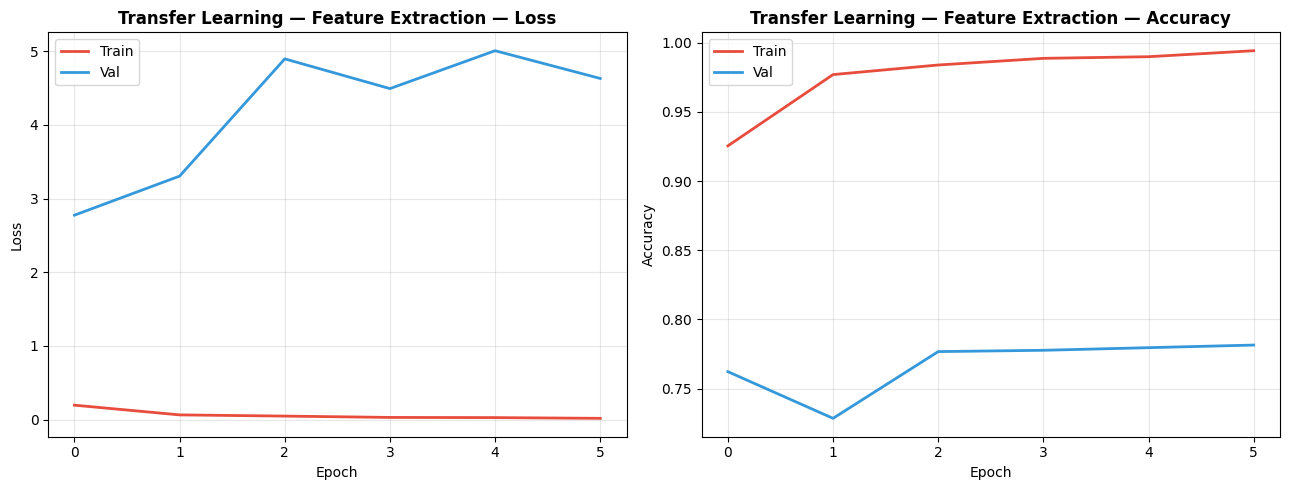

In [37]:
# Cell 20: Step 1 — Feature extraction (frozen base)
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
tl_history_frozen = tl_model.fit(
    train_gen_tl,
    epochs=20,
    validation_data=val_gen_tl,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ],
    verbose=1
)
tl_time = time.time() - start
print(f"\nFeature extraction training time: {tl_time:.1f}s")

plot_history(tl_history_frozen, "Transfer Learning — Feature Extraction",
             save_path="tl_frozen_curves_11.png")

### Cell 21 — Fine-Tune (Unfreeze top layers)

Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 86s 175ms/step - accuracy: 0.9082 - loss: 0.2653 - val_accuracy: 0.7935 - val_loss: 3.3907 - learning_rate: 1.0000e-05
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 54s 136ms/step - accuracy: 0.9739 - loss: 0.0719 - val_accuracy: 0.8042 - val_loss: 3.3947 - learning_rate: 1.0000e-05
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 54s 136ms/step - accuracy: 0.9839 - loss: 0.0513 - val_accuracy: 0.8077 - val_loss: 3.4137 - learning_rate: 1.0000e-05
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9903 - loss: 0.0300
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
397/397 ━━━━━━━━━━━━━━━━━━━━ 53s 134ms/step - accuracy: 0.9903 - loss: 0.0300 - val_accuracy: 0.8052 - val_loss: 3.4368 - learning_rate: 1.0000e-05
Epoch 5/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 53s 134ms/step - accuracy: 0.9897 - loss: 0.0308 - val_accuracy: 0.8061 - val_loss: 3.4160 - learning_rate: 5.0000e-06
Epoch 6/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 53s 134ms/st

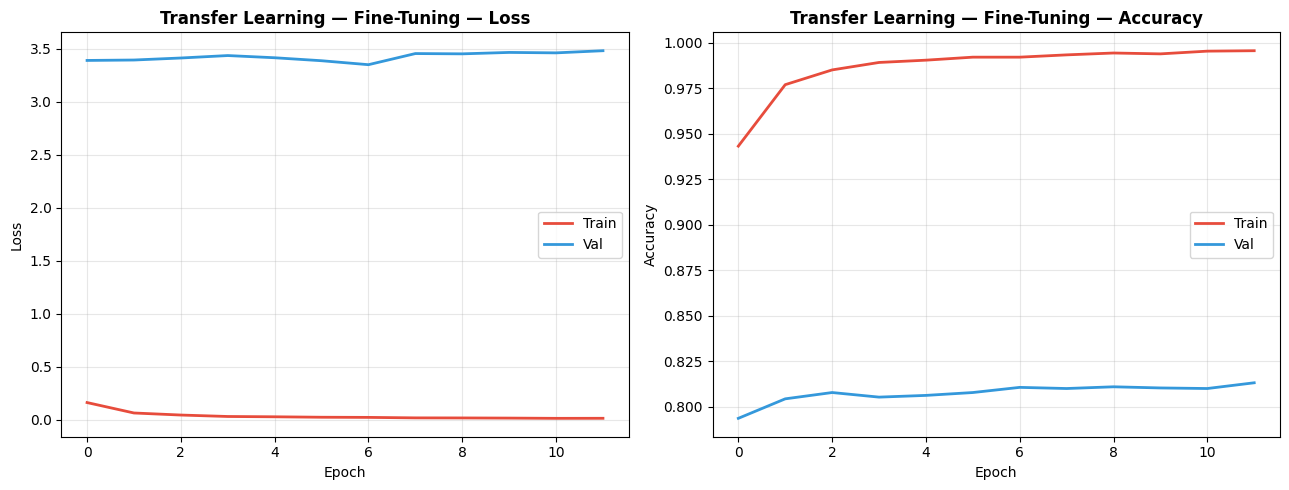

In [38]:
# Cell 21: Step 2 — Fine-tuning (unfreeze last 30 layers of base model)
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate to avoid catastrophic forgetting
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_history_finetune = tl_model.fit(
    train_gen_tl,
    epochs=15,
    validation_data=val_gen_tl,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
    ],
    verbose=1
)

plot_history(tl_history_finetune, "Transfer Learning — Fine-Tuning",
             save_path="tl_finetune_curves_12.png")

### Cell 22 — Evaluate Transfer Learning

=== TRANSFER LEARNING (MobileNetV2) EVALUATION ===
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step
  Validation Loss     : 3.3505
  Validation Accuracy : 81.05%

              precision    recall  f1-score   support

     Caution     0.4759    0.9979    0.6444       484
Instructions     0.6800    0.0599    0.1100       568
  No Passing     0.9874    0.9534    0.9701      1072
   OverSpeed     0.9627    0.9847    0.9736      1048

    accuracy                         0.8105      3172
   macro avg     0.7765    0.7490    0.6745      3172
weighted avg     0.8462    0.8105    0.7675      3172



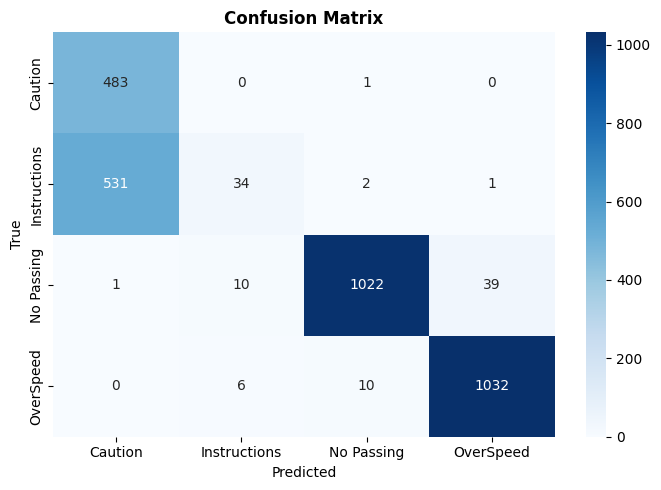

2026-05-09 16:35:59.081353: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 16:35:59.217838: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18431371..0.38823533].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.25490195..0.30196083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2235294..0.36470592].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..

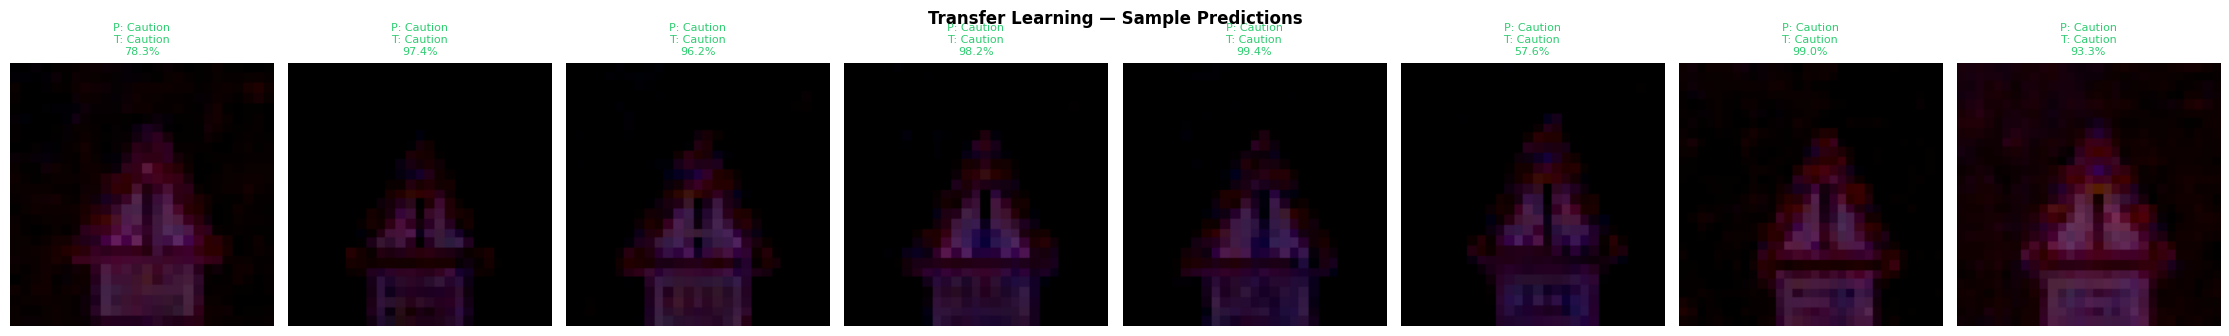

In [39]:
# Cell 22: Evaluate transfer learning model
print("=== TRANSFER LEARNING (MobileNetV2) EVALUATION ===")
tl_loss, tl_acc, tl_preds, tl_labels = evaluate_model(
    tl_model, val_gen_tl, CLASS_NAMES, save_cm_path="tl_cm_13.png"
)

show_predictions(tl_model, val_gen_tl, CLASS_NAMES,
                 title="Transfer Learning — Sample Predictions",
                 save_path="tl_preds_14.png")

### Cell 23 — Final Comparison

In [41]:
# Cell 23: Final comparison — all models
print("\n" + "=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)
print(f"{'Model':<35} {'Val Accuracy':>12}")
print("-" * 60)
print(f"{'Baseline CNN (Adam, scratch)':<35} {base_acc*100:>11.2f}%")
print(f"{'Deeper CNN (Adam, scratch)':<35} {deep_acc*100:>11.2f}%")
print(f"{'Deeper CNN (SGD, scratch)':<35} {sgd_acc*100:>11.2f}%")
print(f"{'Deeper CNN (No BatchNorm)':<35} {no_bn_acc*100:>11.2f}%")
print(f"{'MobileNetV2 Transfer Learning':<35} {tl_acc*100:>11.2f}%")
print("=" * 60)
print("\nConclusion: Transfer learning typically outperforms training")
print("from scratch, especially with limited labeled data.")


FINAL MODEL COMPARISON
Model                               Val Accuracy
------------------------------------------------------------
Baseline CNN (Adam, scratch)              83.07%
Deeper CNN (Adam, scratch)                83.13%
Deeper CNN (SGD, scratch)                 50.03%
Deeper CNN (No BatchNorm)                 77.59%
MobileNetV2 Transfer Learning             81.05%

Conclusion: Transfer learning typically outperforms training
from scratch, especially with limited labeled data.
